# Otimização Optuna

In [7]:
%load_ext autoreload
%autoreload 2

from src.Classification.Optimizer import ClassificationOptunaOptimizer
from src.Data.Processor import DataStreamProcessor
import pandas as pd

# Definição dos datasets
categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Fwd Packet Length Min',
    'Total Fwd Packets',
    'Fwd Packet Length Max',
    'Packet Length Variance',
    'Init_Win_bytes_forward',
    'Flow IAT Mean',
    'Fwd Packets/s',
    'Fwd Packet Length Std',
    'Flow Duration',
    'Total Backward Packets',
    'URG Flag Count',
    'Init_Win_bytes_backward',
    'Flow IAT Min',
    'Bwd Packets/s',
    'Bwd IAT Mean',
    'Down/Up Ratio',
    'Bwd IAT Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Fwd Header Length',
    'Total Length of Fwd Packets',
    'ACK Flag Count',
    'Active Mean',
    'Fwd Packet Length Mean',
    'Fwd PSH Flags',
]

for dataset_path in datasets:
    print(f"\nIniciando otimização para: {dataset_path}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol'],
        imputation_method='mediana'
    )
    
    optimizer = ClassificationOptunaOptimizer(
        stream=stream,
        n_trials=5,
        target_class='macro',
        target_class_pass=0
    )

    # melhor_lb = optimizer.optimize('LB')
    melhot_hat = optimizer.optimize('HAT')
    # melhot_arf = optimizer.optimize('ARF')
    # melhot_ht = optimizer.optimize('HT')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Iniciando otimização para: data/15k/Consistência/Consistência_25.csv

[HAT] Iniciando otimização focada no F1-Score (Classe macro) com 5 trials...
Trial 1/5 | F1: 94.25 | Prec: 99.11 | Rec: 90.27 | Params: {'grace_period': 80, 'split_criterion': 'InfoGainSplitCriterion', 'confidence': 0.0011787131520022709, 'tie_threshold': 0.03755015375953248, 'leaf_prediction': 'NaiveBayes', 'nb_threshold': 1, 'binary_split': False}
Trial 2/5 | F1: 49.88 | Prec: 49.76 | Rec: 49.99 | Params: {'grace_period': 110, 'split_criterion': 'InfoGainSplitCriterion', 'confidence': 0.0009222649230197105, 'tie_threshold': 0.0847269436688078, 'leaf_prediction': 'MajorityClass', 'nb_threshold': 29, 'binary_split': False}
Trial 3/5 | F1: 93.82 | Prec: 99.09 | Rec: 89.58 | Params: {'grace_period': 120, 'split_criterion': 'GiniSplitCriterion', 'confidence': 0.009982475298019107, 'tie_threshold': 0.1381643891156673, 'leaf_predictio

[W 2026-03-30 18:34:10,643] Trial 0 failed with parameters: {'grace_period': 20, 'split_criterion': 'InfoGainSplitCriterion', 'confidence': 0.04262713109712139, 'tie_threshold': 0.051747702582827036, 'leaf_prediction': 'NaiveBayesAdaptive', 'nb_threshold': 45, 'binary_split': True} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\GitHub\anomaly-and-classification-data-stream\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "c:\GitHub\anomaly-and-classification-data-stream\src\Classification\Optimizer.py", line 127, in objective_wrapper
    f1, prec, rec = self._objective_hat(trial)
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\GitHub\anomaly-and-classification-data-stream\src\Classification\Optimizer.py", line 5, in _objective_hat
    from src.Classification.Results import Metrics
                   ^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

# Execução Pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Iniciando treinamento para: Consistência_25

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.96    | 99.92    | 100.00   | 0.33      
  -> Ataque 1 (CLASSE 0): Passagem: -0.07%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 2 (CLASSE 0): Passagem: -0.02%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 3 (CLASSE 0): Passagem: -0.02%   | Recuperação (1000 amostras): +0.00%



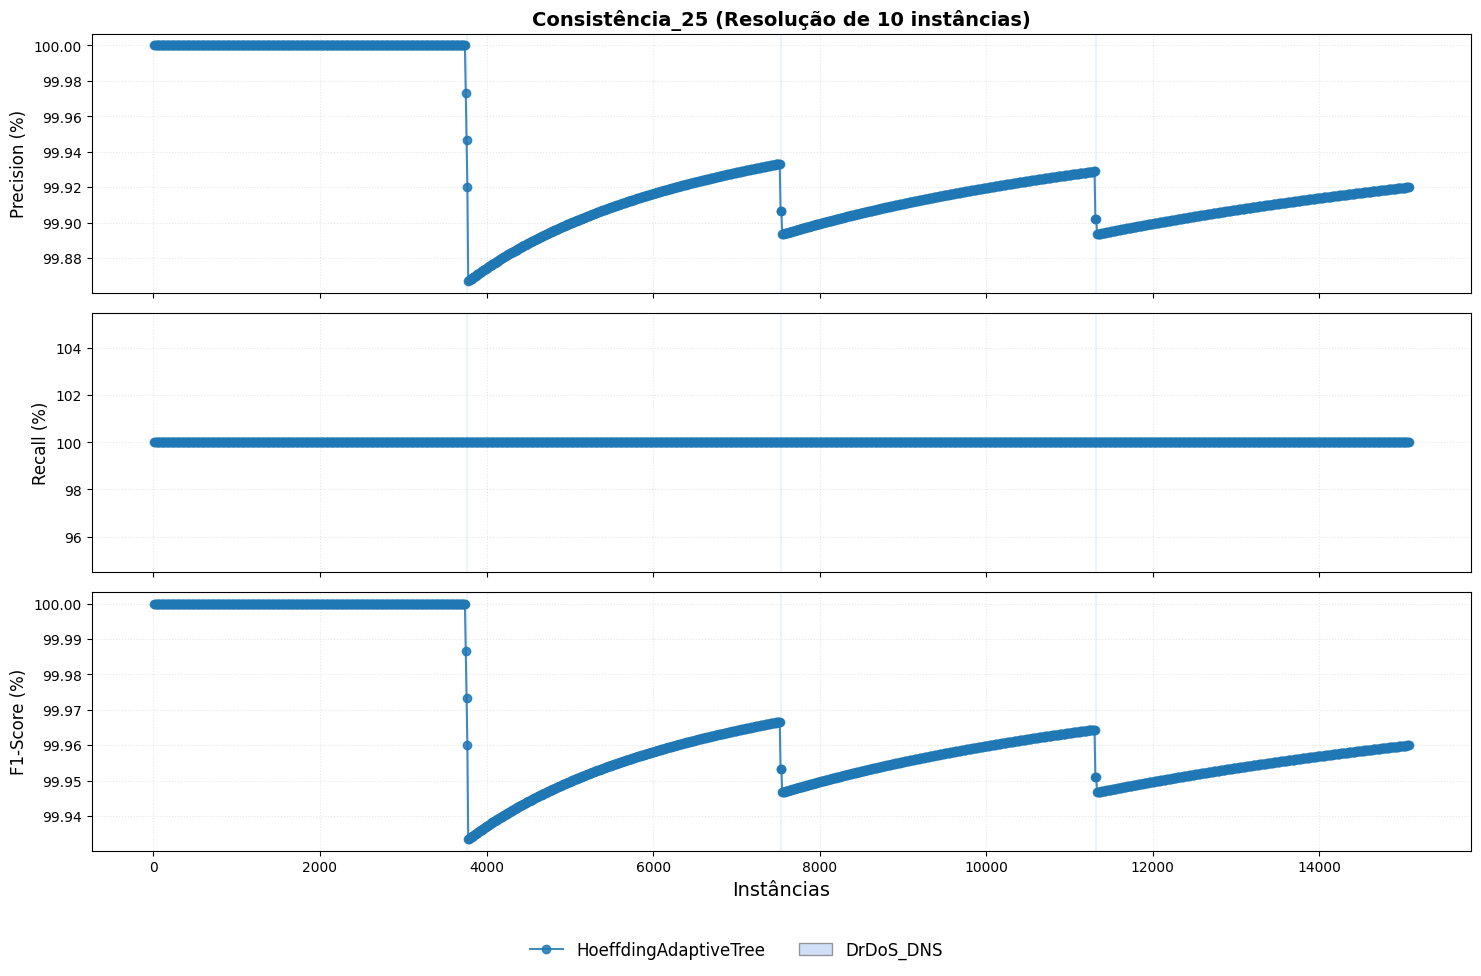


Iniciando treinamento para: Consistência_200

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.81    | 99.67    | 99.96    | 0.44      
  -> Ataque 1 (CLASSE 0): Passagem: -0.16%   | Recuperação (1000 amostras): -0.01%
  -> Ataque 2 (CLASSE 0): Passagem: -0.10%   | Recuperação (1000 amostras): +0.02%
  -> Ataque 3 (CLASSE 0): Passagem: -0.10%   | Recuperação (1000 amostras): +0.02%



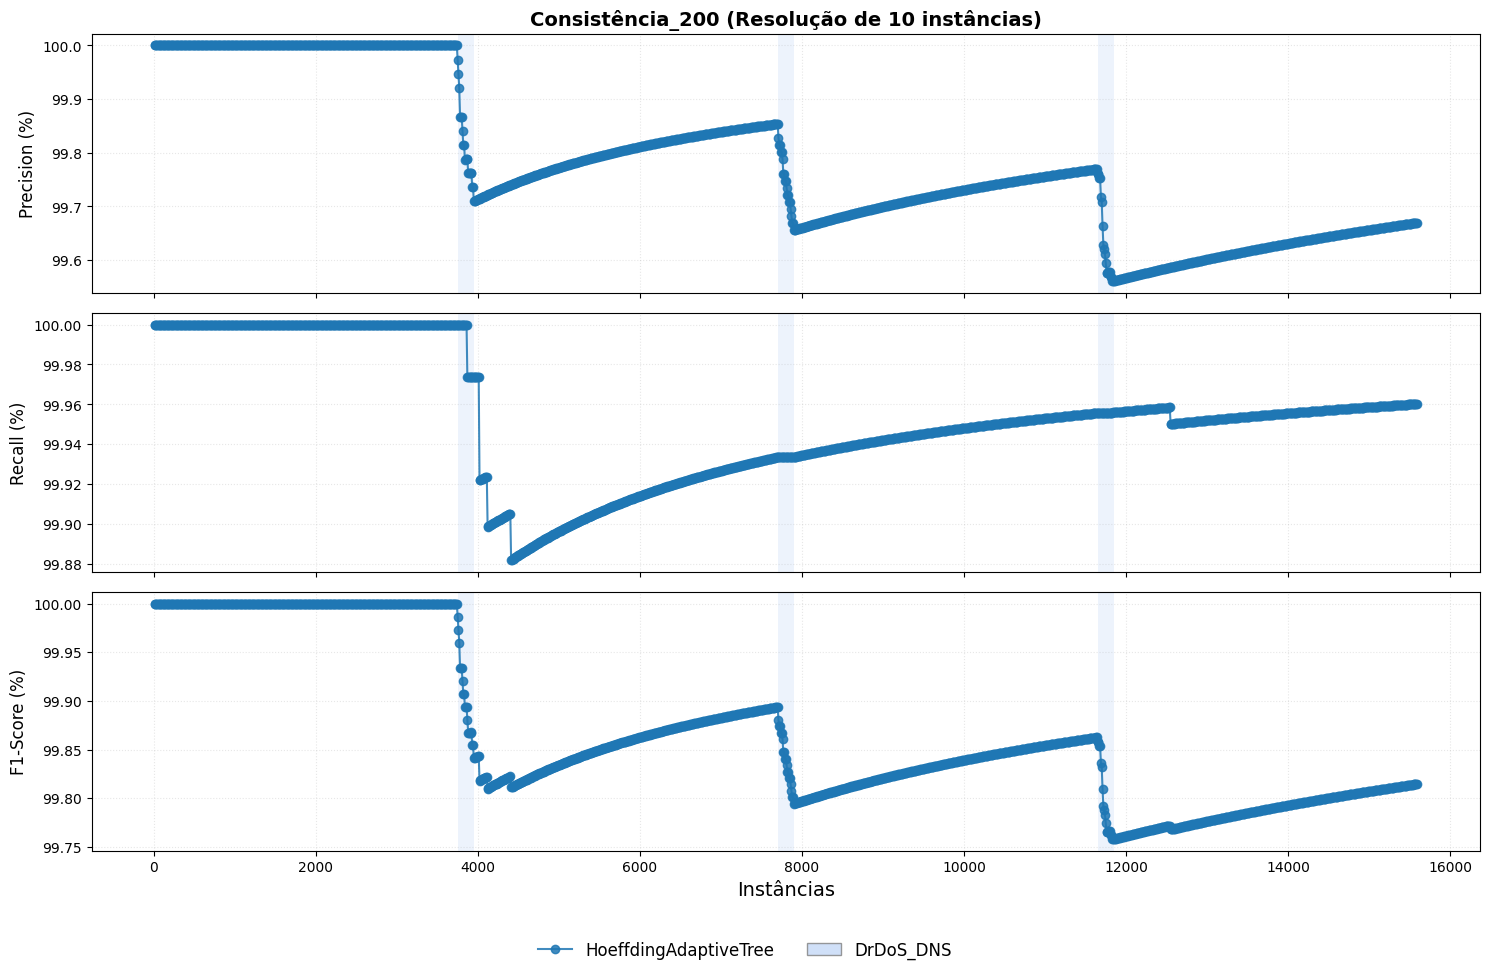


Iniciando treinamento para: Consistência_1000

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.55    | 99.50    | 99.60    | 0.56      
  -> Ataque 1 (CLASSE 0): Passagem: -0.56%   | Recuperação (1000 amostras): +0.08%
  -> Ataque 2 (CLASSE 0): Passagem: -0.28%   | Recuperação (1000 amostras): -0.02%
  -> Ataque 3 (CLASSE 0): Passagem: -0.08%   | Recuperação (1000 amostras): +0.04%



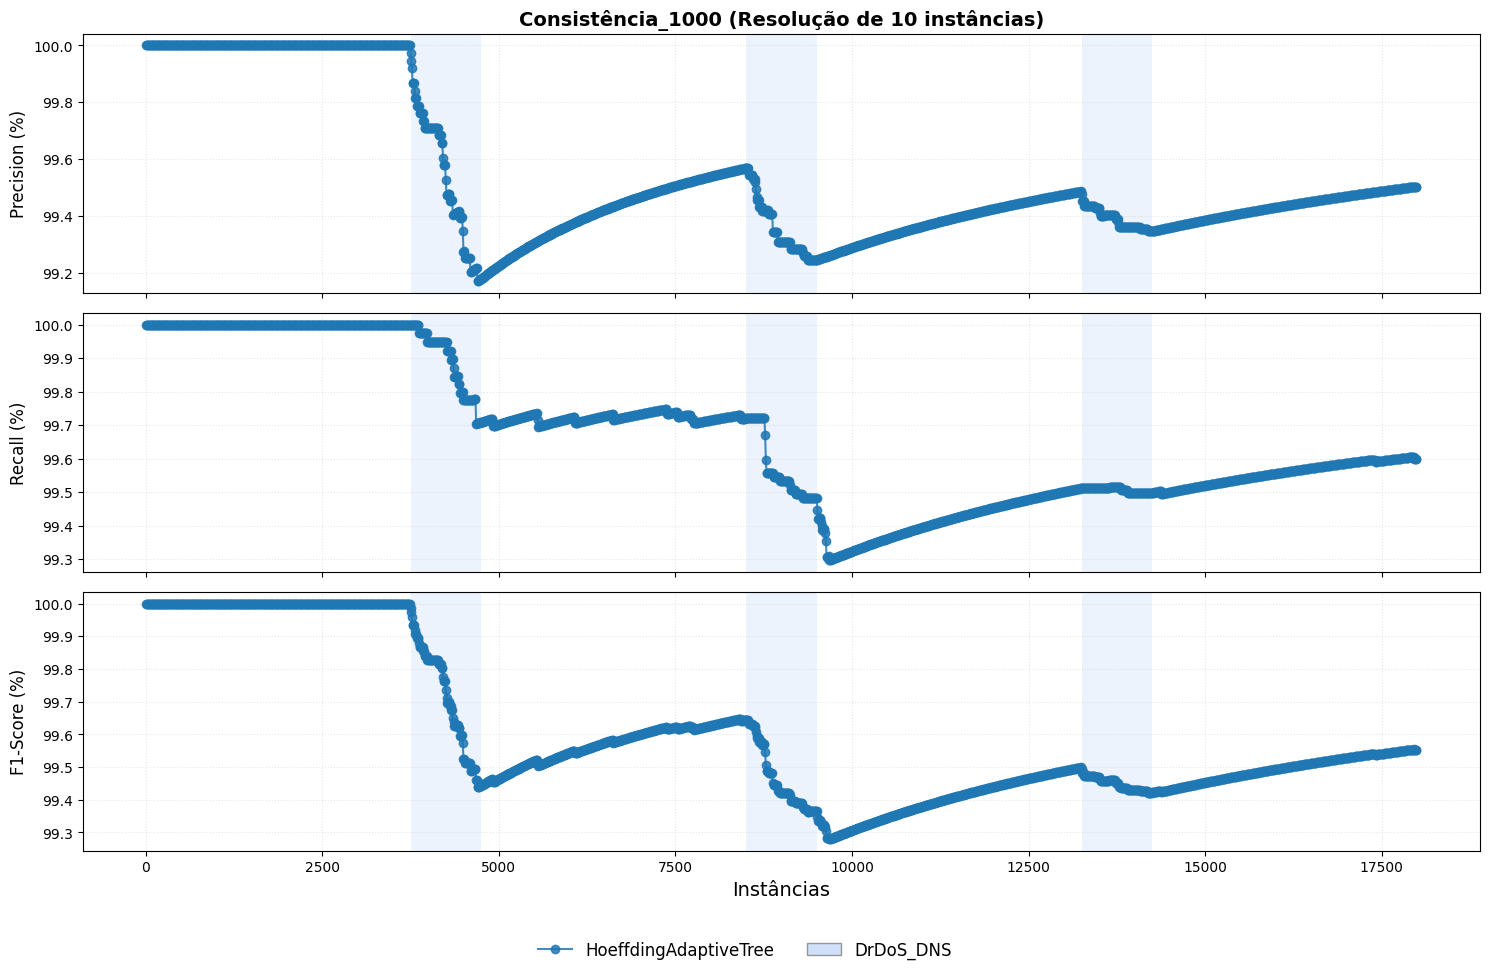


Iniciando treinamento para: Generalização_25

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.97    | 99.93    | 100.00   | 0.36      
  -> Ataque 1 (CLASSE 0): Passagem: -0.07%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 2 (CLASSE 0): Passagem: -0.01%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 3 (CLASSE 0): Passagem: -0.01%   | Recuperação (1000 amostras): +0.00%



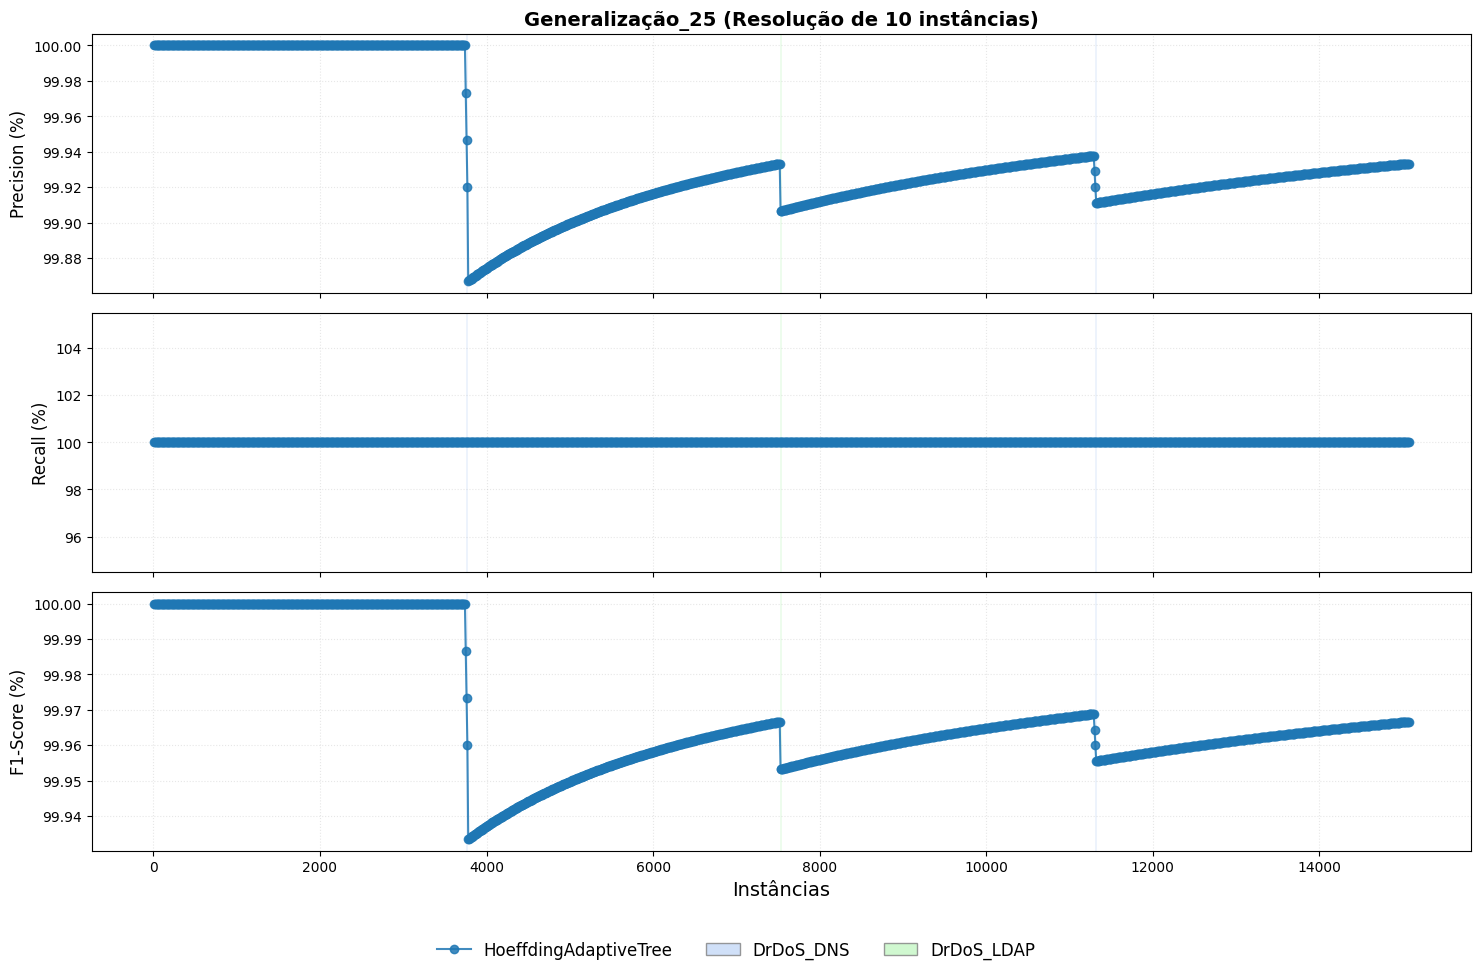


Iniciando treinamento para: Generalização_200

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.83    | 99.75    | 99.91    | 0.47      
  -> Ataque 1 (CLASSE 0): Passagem: -0.16%   | Recuperação (1000 amostras): -0.01%
  -> Ataque 2 (CLASSE 0): Passagem: -0.13%   | Recuperação (1000 amostras): +0.03%
  -> Ataque 3 (CLASSE 0): Passagem: -0.03%   | Recuperação (1000 amostras): -0.01%



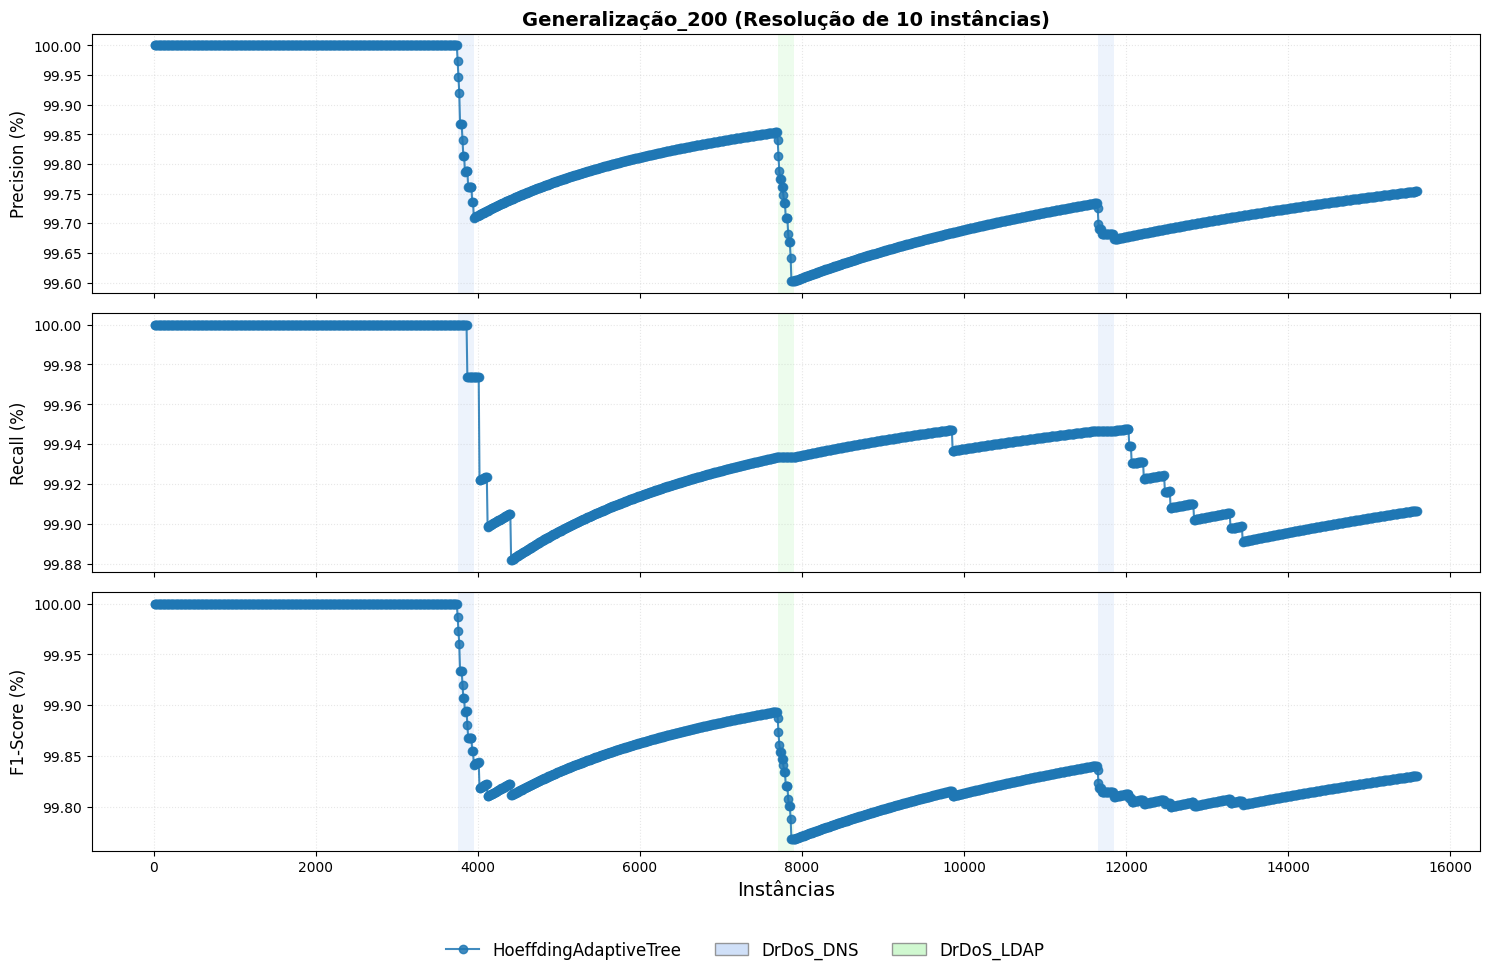


Iniciando treinamento para: Generalização_1000

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.45    | 99.16    | 99.74    | 0.51      
  -> Ataque 1 (CLASSE 0): Passagem: -0.56%   | Recuperação (1000 amostras): +0.08%
  -> Ataque 2 (CLASSE 0): Passagem: -0.21%   | Recuperação (1000 amostras): +0.04%
  -> Ataque 3 (CLASSE 0): Passagem: -0.29%   | Recuperação (1000 amostras): +0.03%



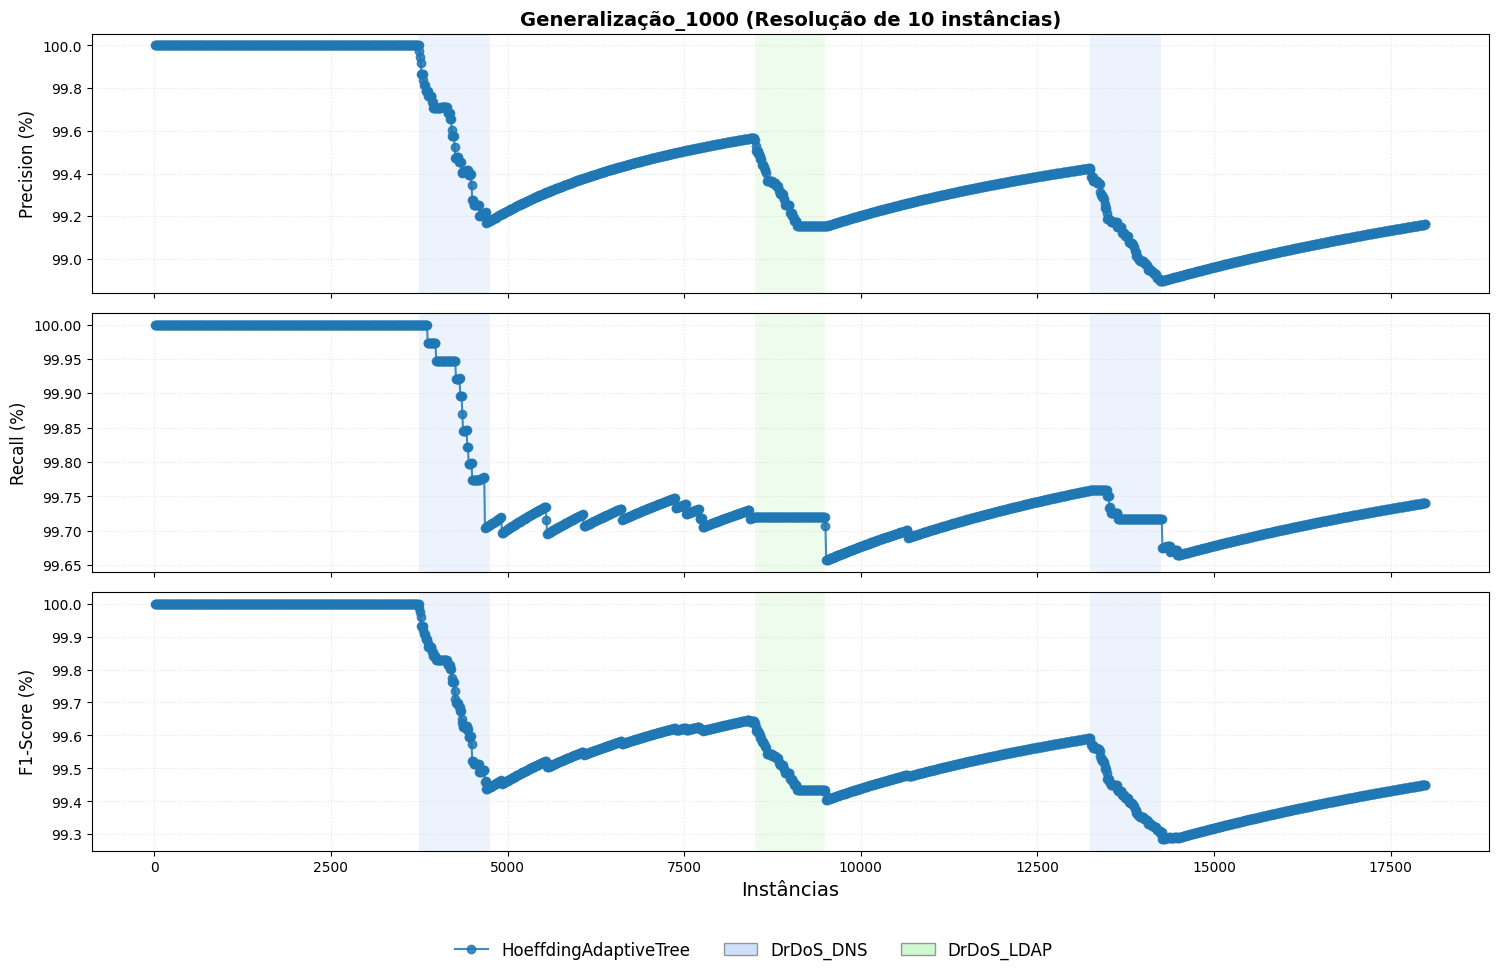


Iniciando treinamento para: Adaptação_25

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.95    | 99.91    | 100.00   | 0.37      
  -> Ataque 1 (CLASSE 0): Passagem: -0.07%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 2 (CLASSE 0): Passagem: -0.04%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 3 (CLASSE 0): Passagem: -0.01%   | Recuperação (1000 amostras): +0.01%



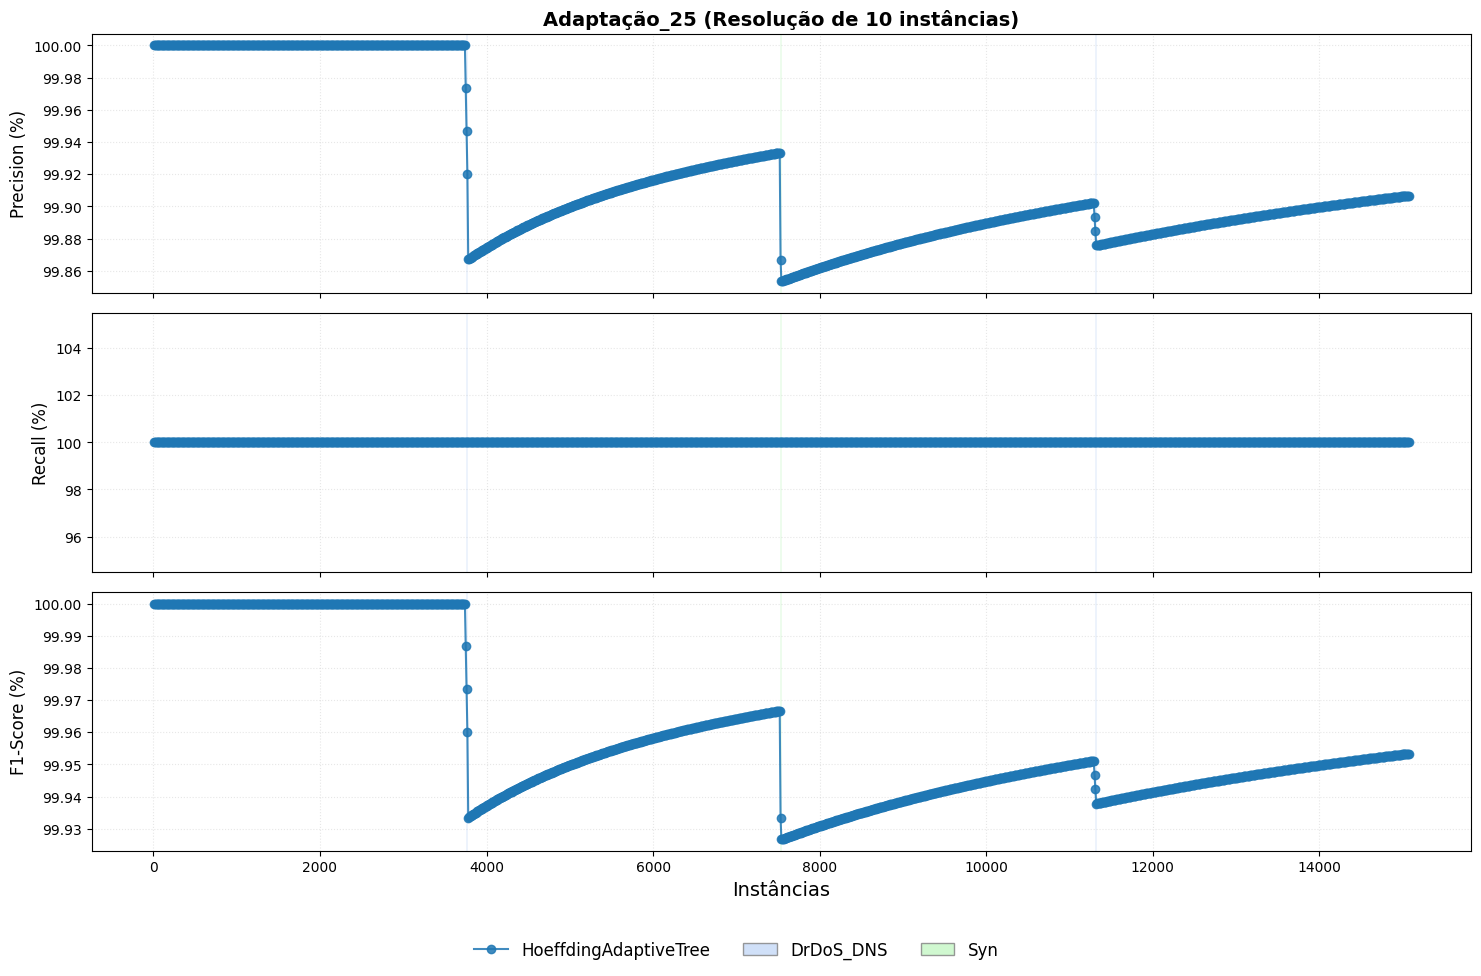


Iniciando treinamento para: Adaptação_200

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.85    | 99.77    | 99.93    | 0.39      
  -> Ataque 1 (CLASSE 0): Passagem: -0.16%   | Recuperação (1000 amostras): -0.01%
  -> Ataque 2 (CLASSE 0): Passagem: -0.09%   | Recuperação (1000 amostras): -0.00%
  -> Ataque 3 (CLASSE 0): Passagem: -0.04%   | Recuperação (1000 amostras): +0.01%



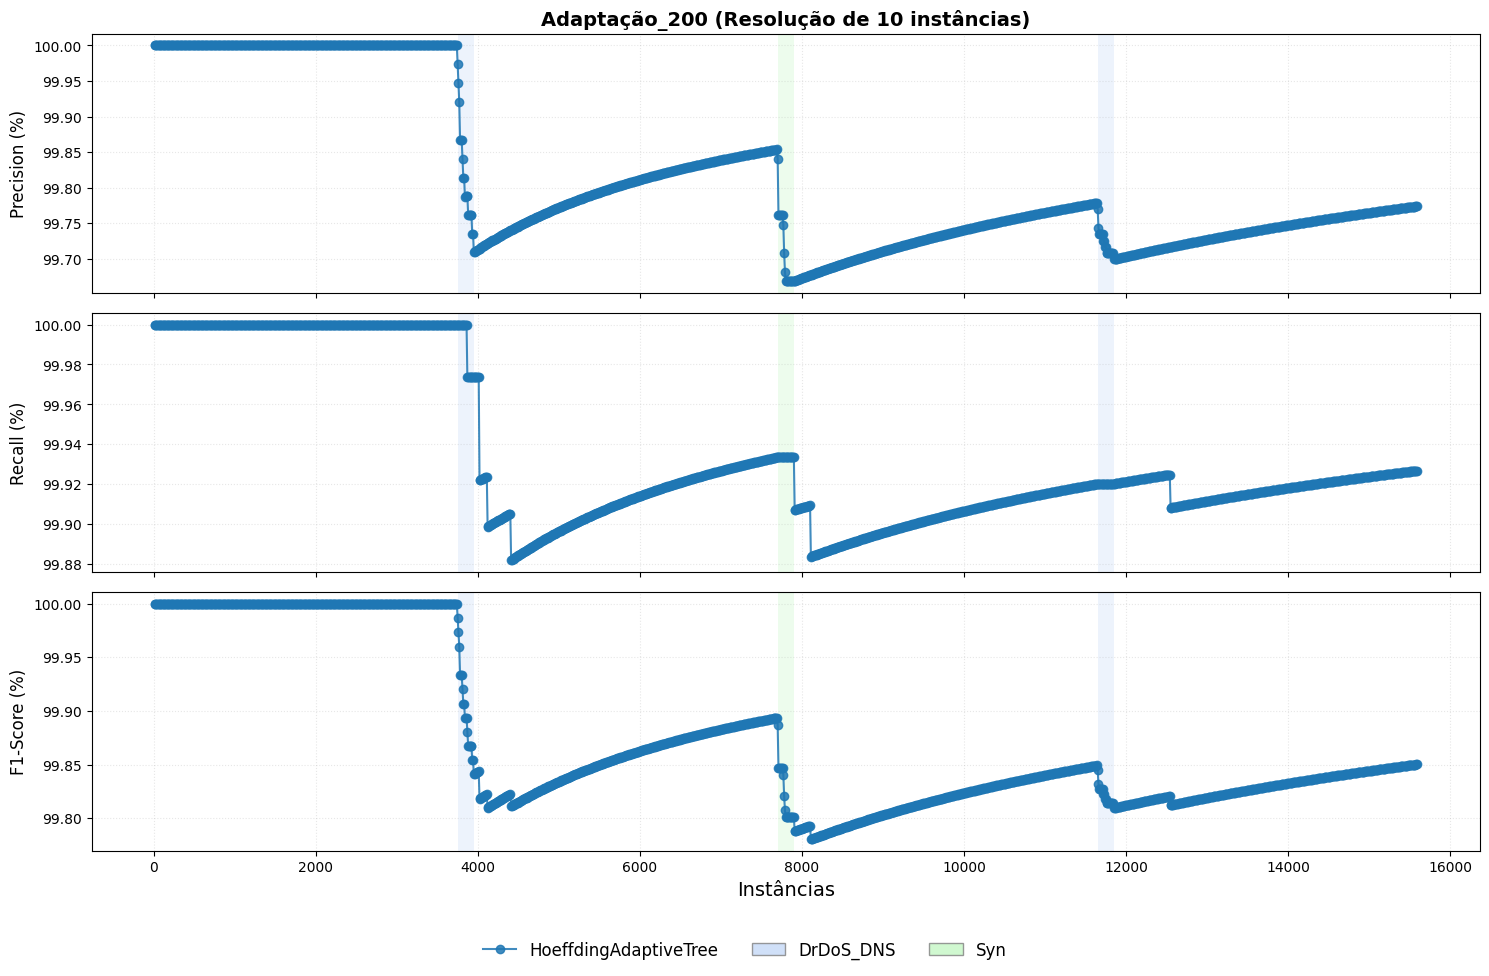


Iniciando treinamento para: Adaptação_1000

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.30    | 98.84    | 99.76    | 0.59      
  -> Ataque 1 (CLASSE 0): Passagem: -0.56%   | Recuperação (1000 amostras): +0.08%
  -> Ataque 2 (CLASSE 0): Passagem: -0.66%   | Recuperação (1000 amostras): +0.07%
  -> Ataque 3 (CLASSE 0): Passagem: -0.17%   | Recuperação (1000 amostras): +0.06%



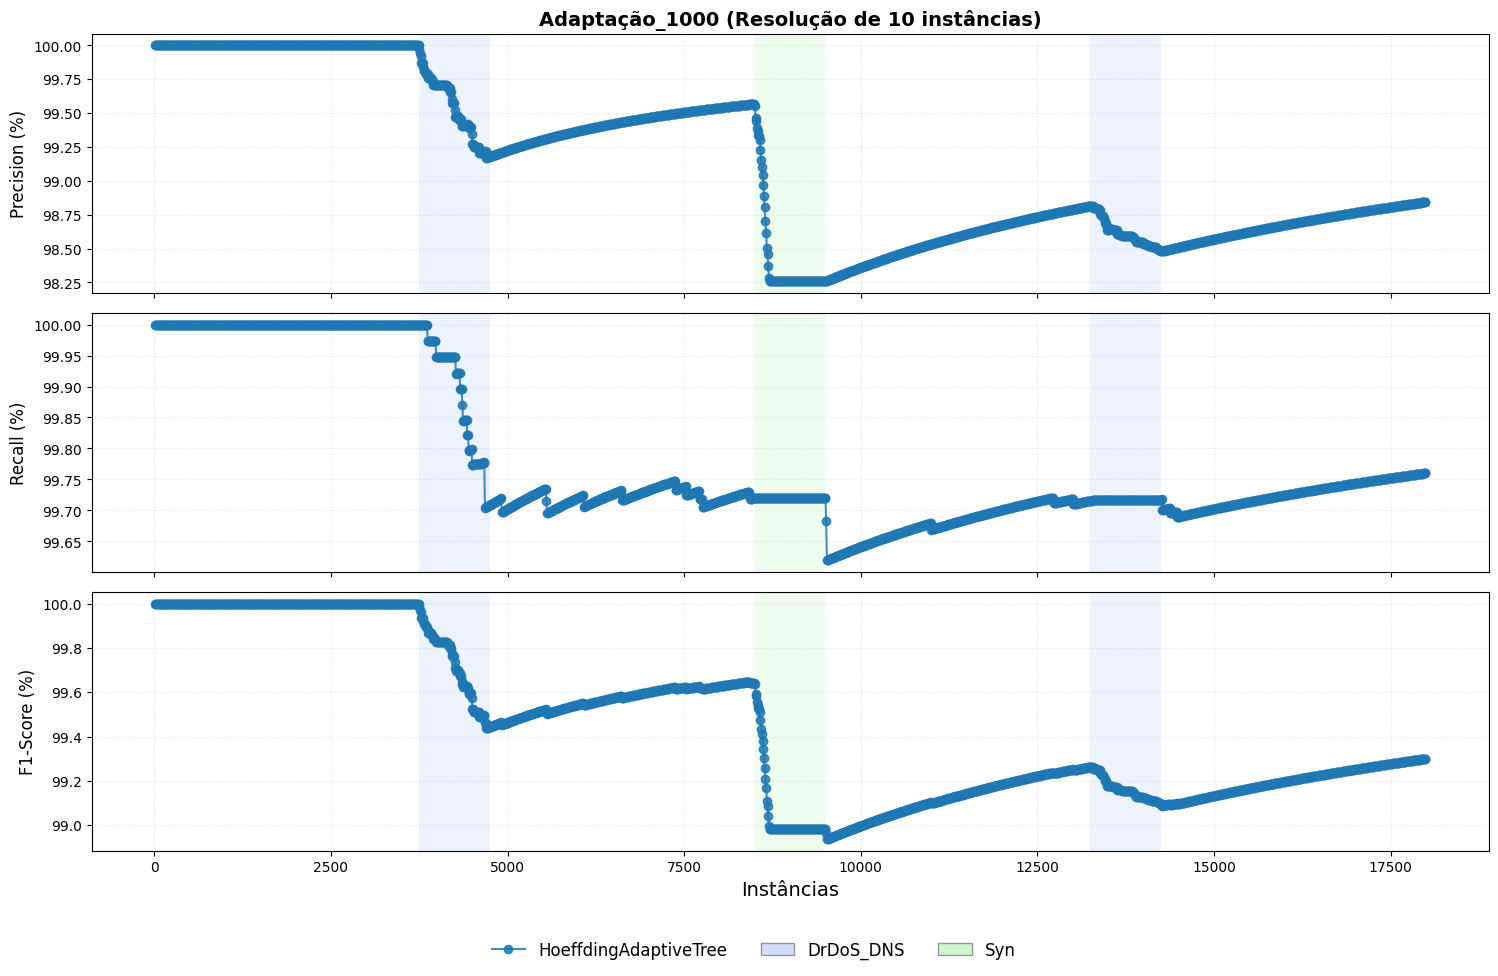


Iniciando treinamento para: Recorrência_25

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.90    | 99.80    | 99.99    | 0.36      
  -> Ataque 1 (CLASSE 0): Passagem: -0.05%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 2 (CLASSE 0): Passagem: -0.10%   | Recuperação (1000 amostras): +0.02%
  -> Ataque 3 (CLASSE 0): Passagem: -0.02%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 4 (CLASSE 0): Passagem: -0.06%   | Recuperação (1000 amostras): +0.02%
  -> Ataque 5 (CLASSE 0): Passagem: -0.01%   | Recuperação (1000 amostras): +0.01%
  -> Ataque 6 (CLASSE 0): Passagem: -0.01%   | Recuperação (1000 amostras): +0.00%



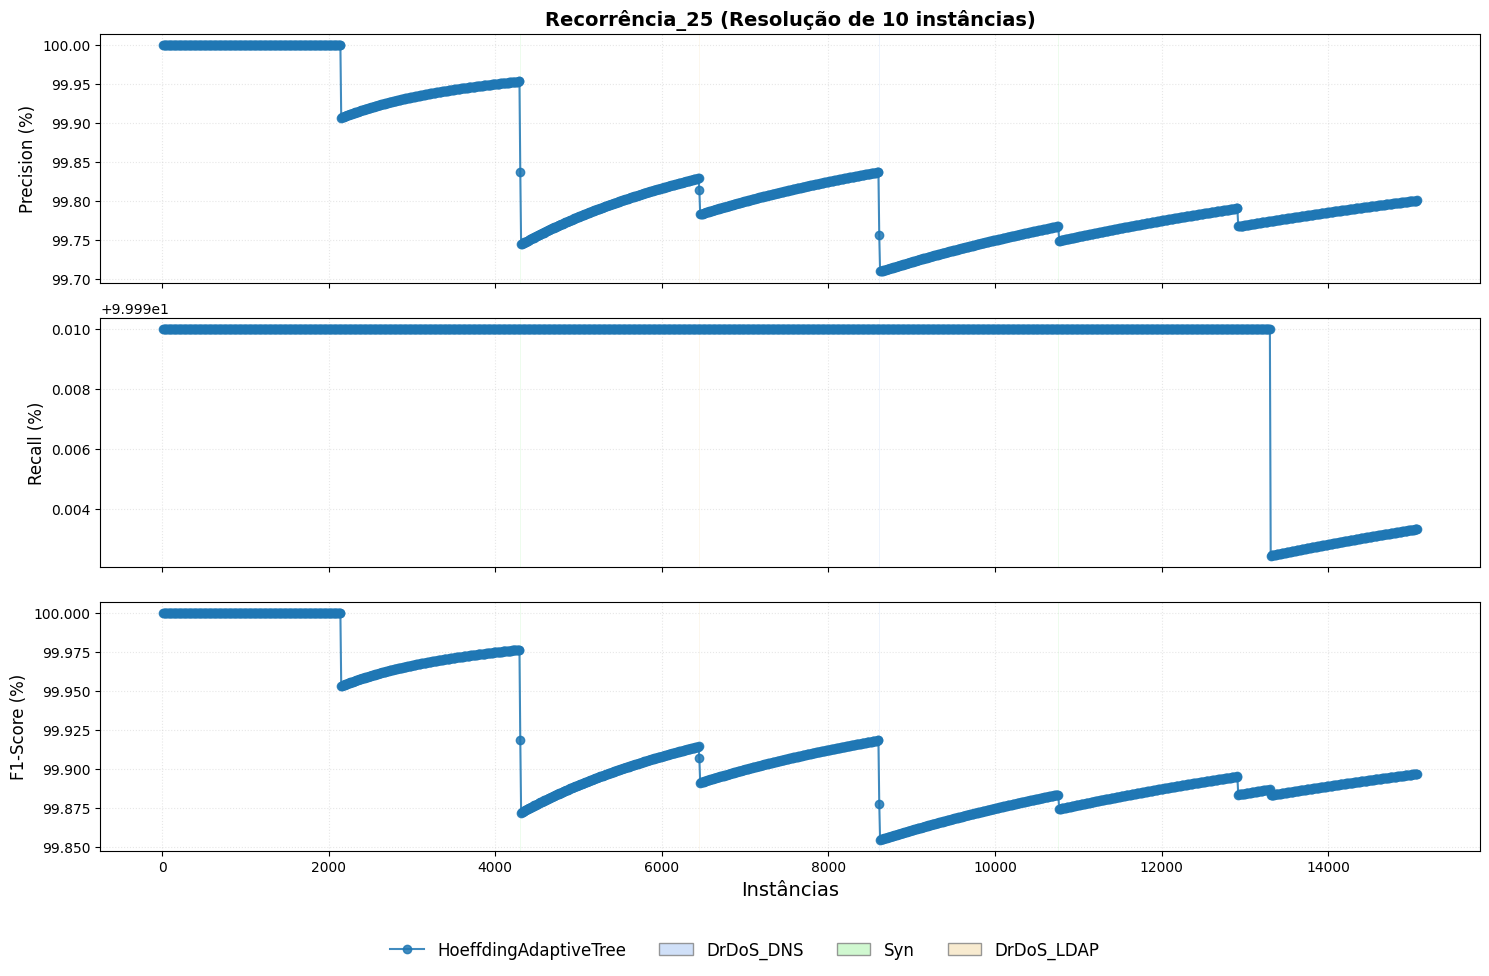


Iniciando treinamento para: Recorrência_200

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.85    | 99.72    | 99.98    | 0.52      
  -> Ataque 1 (CLASSE 0): Passagem: -0.16%   | Recuperação (1000 amostras): +0.02%
  -> Ataque 2 (CLASSE 0): Passagem: -0.17%   | Recuperação (1000 amostras): +0.04%
  -> Ataque 3 (CLASSE 0): Passagem: -0.02%   | Recuperação (1000 amostras): +0.03%
  -> Ataque 4 (CLASSE 0): Passagem: -0.03%   | Recuperação (1000 amostras): +0.02%
  -> Ataque 5 (CLASSE 0): Passagem: -0.03%   | Recuperação (1000 amostras): +0.02%
  -> Ataque 6 (CLASSE 0): Passagem: -0.02%   | Recuperação (1000 amostras): +0.01%



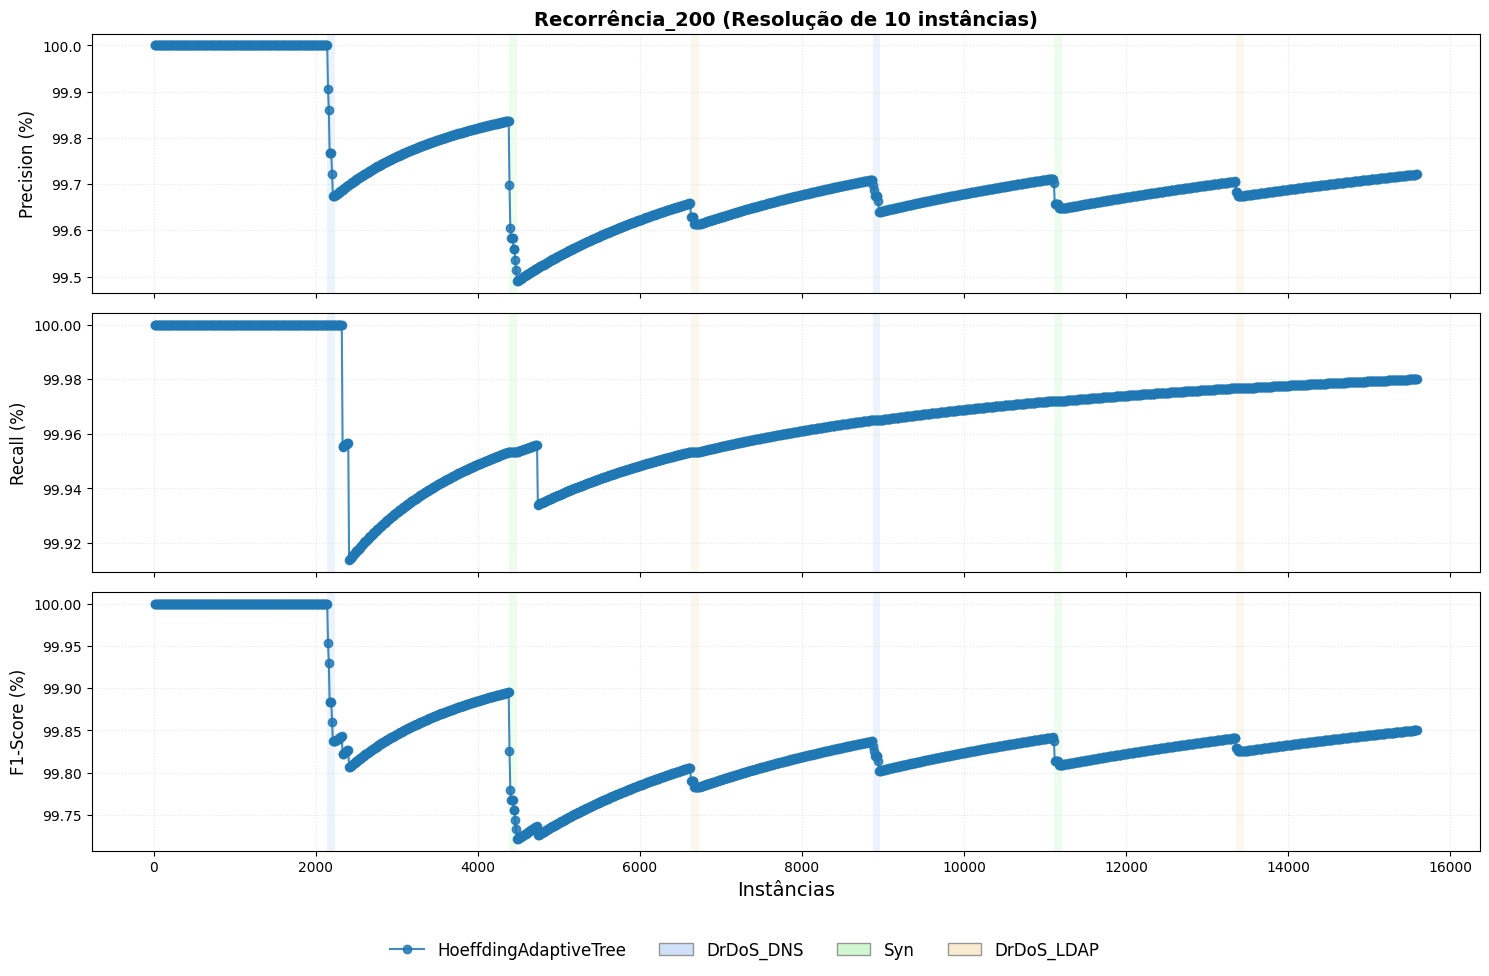


Iniciando treinamento para: Recorrência_1000

  RELATÓRIO COMPORTAMENTAL | Geral: CLASSE 0 | Comportamento: CLASSE 0  
Modelo                    | F1 (%)   | Prec (%) | Rec (%)  | Tempo (s) 
------------------------------------------------------------------------
HoeffdingAdaptiveTree     | 99.09    | 98.40    | 99.79    | 0.51      
  -> Ataque 1 (CLASSE 0): Passagem: -0.28%   | Recuperação (1000 amostras): -0.12%
  -> Ataque 2 (CLASSE 0): Passagem: -1.83%   | Recuperação (1000 amostras): +0.31%
  -> Ataque 3 (CLASSE 0): Passagem: -0.02%   | Recuperação (1000 amostras): +0.20%
  -> Ataque 4 (CLASSE 0): Passagem: -0.05%   | Recuperação (1000 amostras): +0.12%
  -> Ataque 5 (CLASSE 0): Passagem: -0.22%   | Recuperação (1000 amostras): +0.06%
  -> Ataque 6 (CLASSE 0): Passagem: -0.02%   | Recuperação (1000 amostras): +0.07%



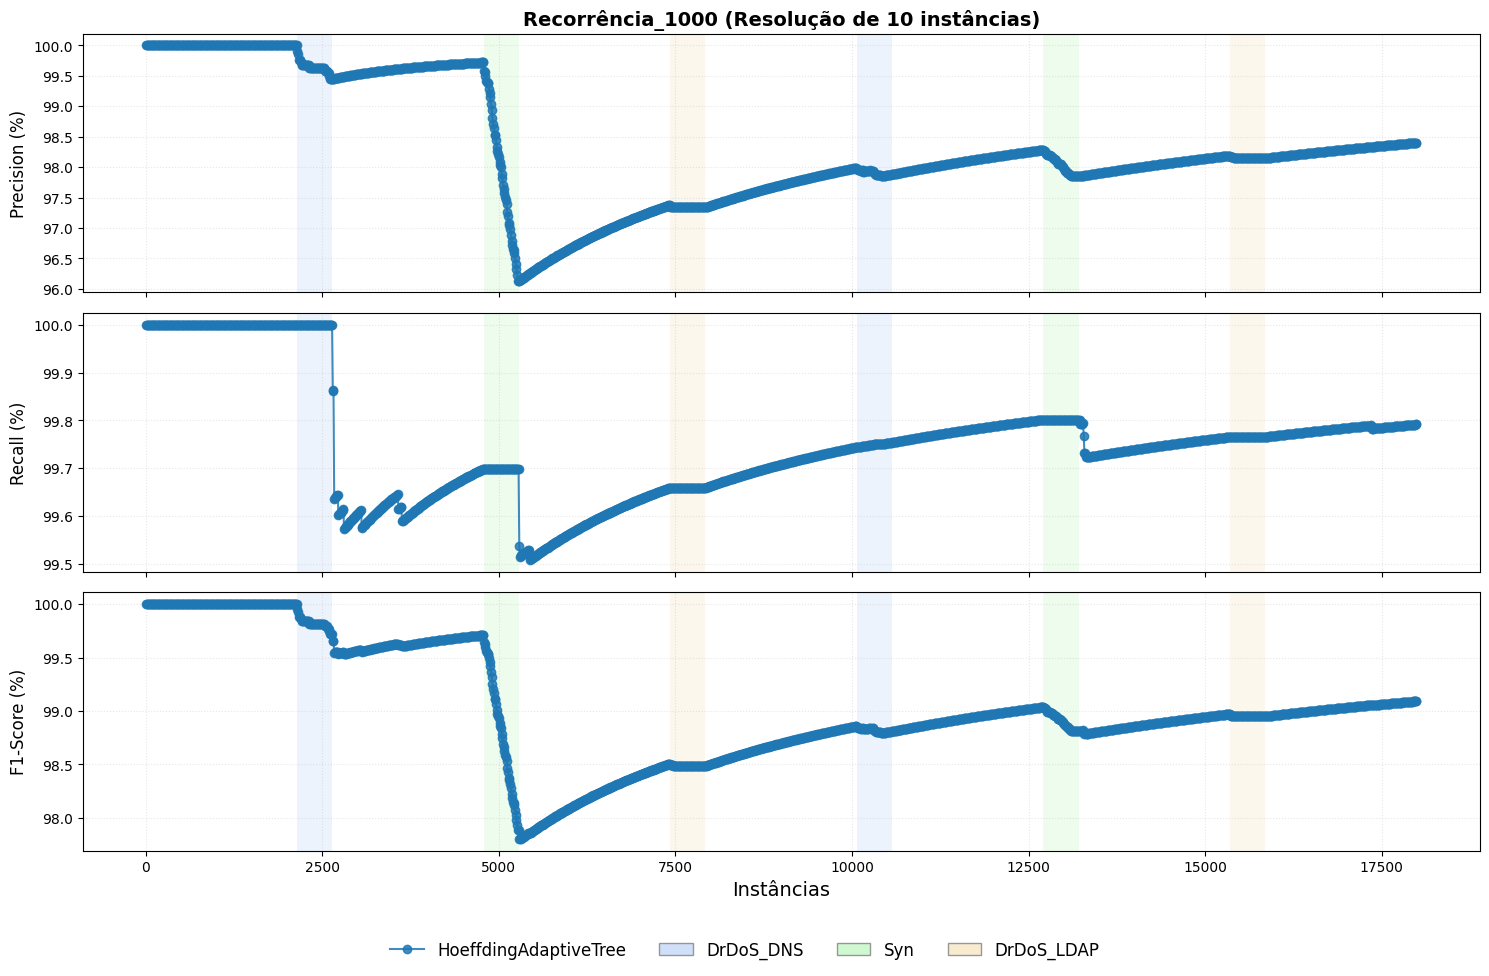

In [4]:
%load_ext autoreload
%autoreload 2

from src.Classification.Pipeline import ClassificationExperimentRunner
from src.Classification.Models import get_classification_models
from src.Data.Processor import DataStreamProcessor
import pandas as pd

categorias = ['Consistência', 'Generalização', 'Adaptação', 'Recorrência']
tamanhos = ['25', '200', '1000']
datasets = [f'data/15k/{cat}/{cat}_{tam}.csv' for cat in categorias for tam in tamanhos]

features = [
    'Fwd Packet Length Min',
    'Total Fwd Packets',
    'Fwd Packet Length Max',
    'Packet Length Variance',
    'Init_Win_bytes_forward',
    'Flow IAT Mean',
    'Fwd Packets/s',
    'Fwd Packet Length Std',
    'Flow Duration',
    'Total Backward Packets',
    'URG Flag Count',
    'Init_Win_bytes_backward',
    'Flow IAT Min',
    'Bwd Packets/s',
    'Bwd IAT Mean',
    'Down/Up Ratio',
    'Bwd IAT Min',
    'Bwd Packet Length Mean',
    'Bwd Packet Length Max',
    'Fwd Header Length',
    'Total Length of Fwd Packets',
    'ACK Flag Count',
    'Active Mean',
    'Fwd Packet Length Mean',
    'Fwd PSH Flags',
]

for dataset_path in datasets:
    nome_experimento = dataset_path.split('/')[-1].replace('.csv', '')
    print(f"\nIniciando treinamento para: {nome_experimento}")
    
    df = pd.read_csv(dataset_path)
    
    processor = DataStreamProcessor(logging=False, selected_features=features)
    
    stream, targets, features = processor.create_stream(
        df=df,
        target_label_col='Label',
        binary_label=False,
        normalize_method="MinMaxScaler",
        threshold_var=None,
        threshold_corr=None,
        top_n_features=None,
        return_stream=True,
        extra_ignore_cols=['Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Inbound'],
        imputation_method='mediana'
    )
    
    algoritmos = get_classification_models(
        stream.get_schema(),
        selected_models=['HAT']
    )
    
    runner = ClassificationExperimentRunner(target_names=targets)
    
    runner.run_classification_evaluation(
        stream,
        algorithms=algoritmos,
        window_size=10,
        warmup_instances=0,
        title=nome_experimento,
        target_class=0,
        target_class_pass=0
    )